<a href="https://colab.research.google.com/github/harshaesmayil/Employee-Attrition-Classifier/blob/main/emp_attrition_week1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

**WEEK 1 - PROJECT 2 [Data Analysis & Feature Engineering]**

---

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv('/content/IBM-HR-Employee-Attrition.csv')

print("---------------- Shape of the dataframe ----------------")
print(df.shape)

---------------- Shape of the dataframe ----------------
(1470, 35)


In [53]:
print("---------------- Column info and datatype ----------------")
print(df.info())

---------------- Column info and datatype ----------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement     

In [54]:
print("---------------- Statistical Description ----------------")
print(df.describe())

---------------- Statistical Description ----------------
               Age    DailyRate  DistanceFromHome    Education  EmployeeCount  \
count  1470.000000  1470.000000       1470.000000  1470.000000         1470.0   
mean     36.923810   802.485714          9.192517     2.912925            1.0   
std       9.135373   403.509100          8.106864     1.024165            0.0   
min      18.000000   102.000000          1.000000     1.000000            1.0   
25%      30.000000   465.000000          2.000000     2.000000            1.0   
50%      36.000000   802.000000          7.000000     3.000000            1.0   
75%      43.000000  1157.000000         14.000000     4.000000            1.0   
max      60.000000  1499.000000         29.000000     5.000000            1.0   

       EmployeeNumber  EnvironmentSatisfaction   HourlyRate  JobInvolvement  \
count     1470.000000              1470.000000  1470.000000     1470.000000   
mean      1024.865306                 2.721769    65.8

In [55]:
print("---------------- Missing value report ----------------")
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0].sort_values(ascending=False))

---------------- Missing value report ----------------
Series([], dtype: int64)


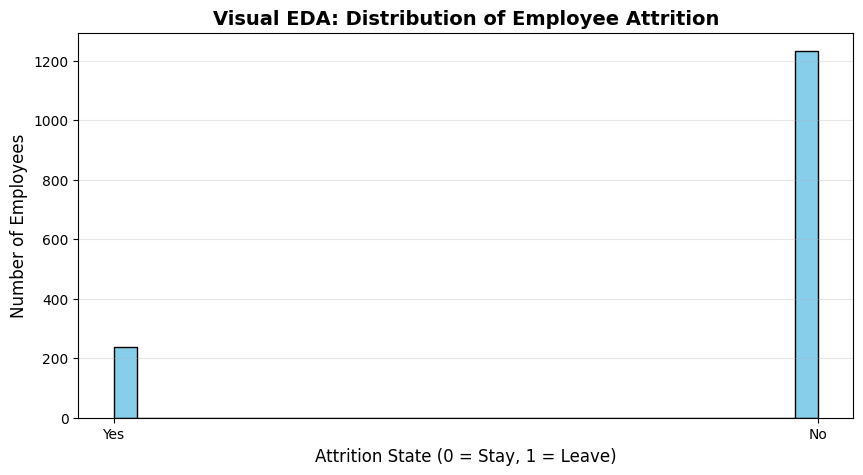

In [56]:
# matplotlib visual eda
plt.figure(figsize=(10, 5))

plt.hist(df['Attrition'].dropna(), bins=30, color='skyblue', edgecolor='black')

plt.title('Visual EDA: Distribution of Employee Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Attrition State (0 = Stay, 1 = Leave)', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()

In [57]:
# new df stores cleaned df where the 2 columns that have too many null values/redundancies are deleted
df_cleaned = df.drop(columns=['EmployeeCount', 'Over18'])

# in the column TotalWorkingYears, in places with blank data, median is filled
total_years_median = df_cleaned['TotalWorkingYears'].median()
df_cleaned['TotalWorkingYears'] = df_cleaned['TotalWorkingYears'].fillna(total_years_median)

print("Remaining missing values in TotalWorkingYears column:", df_cleaned['TotalWorkingYears'].isnull().sum())

Remaining missing values in TotalWorkingYears column: 0


In [58]:
# calculate lower and upper cut
Q1 = df_cleaned['MonthlyIncome'].quantile(0.25)
Q3 = df_cleaned['MonthlyIncome'].quantile(0.75)

#iqr - the mid 50%
IQR=Q3-Q1

#calculate the outliers
lower_fence=Q1-(1.5*IQR)
upper_fence=Q3+(1.5*IQR)

# calculate the outliers
outliers_df = df_cleaned[(df_cleaned['MonthlyIncome'] > upper_fence) | (df_cleaned['MonthlyIncome'] < lower_fence)]

print("Total num of MonthlyIncome outliers detected:", len(outliers_df))

Total num of MonthlyIncome outliers detected: 114


In [59]:
# categorical encoding
# this command creates sep columns and removes redundant columns
df_encoded = pd.get_dummies(df_cleaned, columns=['Department'], drop_first=True)
print("Newly encoded columns:")

# printing the columns with the word Department
dept_columns = [col for col in df_encoded.columns if 'Department' in col]
df_encoded[dept_columns].head()

Newly encoded columns:


,Department_Research & Development,Department_Sales
0,False,True
1,True,False
2,True,False
3,True,False
4,True,False


In [60]:
# scaling strategy
# scaling means we are changing the range of all data so that theyre all similar without losing the meaning
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_columns = ['MonthlyIncome', 'Age', 'DistanceFromHome', 'YearsAtCompany', 'TotalWorkingYears']
df_encoded[num_columns] = scaler.fit_transform(df_encoded[num_columns])
df_encoded[num_columns].head(5)

,MonthlyIncome,Age,DistanceFromHome,YearsAtCompany,TotalWorkingYears
0,-0.108350,0.446350,-1.010909,-0.164613,-0.421642
1,-0.291719,1.322365,-0.147150,0.488508,-0.164511
2,-0.937654,0.008343,-0.887515,-1.144294,-0.550208
3,-0.763634,-0.429664,-0.764121,0.161947,-0.421642
4,-0.644858,-1.086676,-0.887515,-0.817734,-0.678774



**Week 1 - Phase 2:**
**Feature Importance Hypothesis Notes**
---
Target Variable
Attrition is the target variable since in the end we are trying to predict the Attrition which is like an outcome
---
My Hypotheses (Ranked from Most Important to Least Important)
1. Most Critical Predictor:
My Rationale: OverTime and DistanceFromHome is imp because it determines the burnout and exhaustion levels of an employee and that is what makes an employee leave

2. Moderate Predictor:
My Rationale: YearsAtCompany could be a good predictor since people wouldnt prefer to stick around a company for 10 years if they are unhappy, while new hires might leave quickly if onboarding is bad

3. Weakest Predictor:
My Rationale: apparently ID numbers or Gender they possess doesnt have much importance since that doesnt determine much cuz even any group could get high attrition rates
"""

In [61]:
import scipy.stats as stats
import pandas as pd

#lists to hold our clean results
sorted_results = []
df_chi = df_cleaned.copy()

#columns tht are already categories
pure_categories = [
    'BusinessTravel', 'Department', 'Education', 'EducationField',
    'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobLevel',
    'JobRole', 'JobSatisfaction', 'MaritalStatus', 'OverTime',
    'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
    'WorkLifeBalance'
]

#non categorical list
numerical_to_bin = [
    'Age', 'DistanceFromHome', 'MonthlyIncome', 'NumCompaniesWorked',
    'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear',
    'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

#convert every single numeric column into 3 buckets
for col in numerical_to_bin:
    if col in df_chi.columns:
        df_chi[col + '_Group'] = pd.cut(df_chi[col], bins=3, labels=['Low', 'Medium', 'High'])

        #adding to list
        pure_categories.append(col + '_Group')

#--------chi square test logic--------
for col in pure_categories:
    if col in df_chi.columns:
        contingency_table = pd.crosstab(df_chi[col], df_chi['Attrition'])
        chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

        #the status label
        if p_value < 0.05:
            status = "Alt Hypothesis"
        else:
            status = "Null Hypothesis"

        sorted_results.append({'Feature': col, 'p_value': p_value, 'Status': status})

#convert to a DataFrame and sort by p-value (smallest p-value = most important)
df_results = pd.DataFrame(sorted_results)
df_results = df_results.sort_values(by='p_value')

#print a clean, aligned dashboard
print(f"{'Feature Column':<35} | {'p-value':<12} | {'Verdict':<15}")
print("-" * 70)

for index, row in df_results.iterrows():
    # .6f shows 6 decimal places, .3e switches to scientific notation if the number is tiny
    p_fmt = f"{row['p_value']:.6f}" if row['p_value'] > 0.000001 else f"{row['p_value']:.3e}"
    print(f"{row['Feature']:<35} | {p_fmt:<12} | {row['Status']:<15}")

Feature Column                      | p-value      | Verdict        
----------------------------------------------------------------------
OverTime                            | 8.158e-21    | Alt Hypothesis 
JobRole                             | 2.752e-15    | Alt Hypothesis 
JobLevel                            | 6.635e-15    | Alt Hypothesis 
StockOptionLevel                    | 4.379e-13    | Alt Hypothesis 
Age_Group                           | 7.352e-11    | Alt Hypothesis 
MaritalStatus                       | 9.456e-11    | Alt Hypothesis 
JobInvolvement                      | 0.000003     | Alt Hypothesis 
BusinessTravel                      | 0.000006     | Alt Hypothesis 
TotalWorkingYears_Group             | 0.000032     | Alt Hypothesis 
MonthlyIncome_Group                 | 0.000048     | Alt Hypothesis 
EnvironmentSatisfaction             | 0.000051     | Alt Hypothesis 
YearsWithCurrManager_Group          | 0.000177     | Alt Hypothesis 
YearsInCurrentRole_Group        

---

**WEEK 1 - PROJECT 3 [Supervised ML Basics]**

---

In [62]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [63]:
#identify text-datatype columns
df.select_dtypes(include='object').columns

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

In [64]:
#text columns unique values
for col in df.select_dtypes(include='object').columns:
    print(col)
    print(df[col].unique())
    print()

Attrition
['Yes' 'No']

BusinessTravel
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']

Department
['Sales' 'Research & Development' 'Human Resources']

EducationField
['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']

Gender
['Female' 'Male']

JobRole
['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']

MaritalStatus
['Single' 'Married' 'Divorced']

Over18
['Y']

OverTime
['Yes' 'No']



In [65]:
import pandas as pd

# Reload the original DataFrame to ensure a clean state for re-execution.
# This prevents KeyErrors if the cell is run multiple times and 'df'
# has already been transformed (e.g., categorical columns dropped).
df = pd.read_csv('/content/IBM-HR-Employee-Attrition.csv')

#Binary Encoding
binary_cols = {'Attrition': {'No': 0, 'Yes': 1},
               'Gender': {'Female': 0, 'Male': 1},
               'OverTime': {'No': 0, 'Yes': 1}}
for col, mapping in binary_cols.items():
    df[col] = df[col].map(mapping)

#all categorical columns
categorical_cols = [
    'BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus',
    'Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobSatisfaction',
    'PerformanceRating', 'RelationshipSatisfaction', 'WorkLifeBalance'
]

#One-Hot Encoding
# Filter to ensure only columns currently present in df are encoded
cols_to_encode = [col for col in categorical_cols if col in df.columns]
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

# Drop 'Over18' column as it has only one unique value 'Y' and is causing conversion issues.
# This column was also dropped in 'df_cleaned' earlier, so it's consistent with that intent.
if 'Over18' in df.columns:
    df = df.drop(columns=['Over18'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 61 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int64
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   EmployeeCount                      1470 non-null   int64
 5   EmployeeNumber                     1470 non-null   int64
 6   Gender                             1470 non-null   int64
 7   HourlyRate                         1470 non-null   int64
 8   JobLevel                           1470 non-null   int64
 9   MonthlyIncome                      1470 non-null   int64
 10  MonthlyRate                        1470 non-null   int64
 11  NumCompaniesWorked                 1470 non-null   int64
 12  OverTime            

In [66]:
#to seperate everything but target variable
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

# Ensure 'Over18' column is dropped from X if it somehow persisted
# This provides a robust safeguard against the 'Y' string error.
if 'Over18' in X.columns:
    X = X.drop(columns=['Over18'])

print(X.shape)
print(y.shape)

(1470, 60)
(1470,)


In [67]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop any non-numeric columns (e.g., 'object' or 'category' dtypes) from X
# This ensures no string values like 'Y' persist before splitting and scaling.
# Also drop constant or identifier columns that have no predictive power.
columns_to_drop_from_X = []
for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype == 'category':
        columns_to_drop_from_X.append(col)
# Explicitly drop known constant or identifier columns that don't add value
if 'EmployeeCount' in X.columns: columns_to_drop_from_X.append('EmployeeCount')
if 'StandardHours' in X.columns: columns_to_drop_from_X.append('StandardHours')
if 'EmployeeNumber' in X.columns: columns_to_drop_from_X.append('EmployeeNumber')

X = X.drop(columns=list(set(columns_to_drop_from_X)), errors='ignore')

scaler = StandardScaler()

#test=20%, train=80%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#scaler will now only scale truly continuous features
#because get_dummies turns categoricals into 0s and 1s, scaling them is unnecessary

continuous_cols = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate',
    'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
    'TotalWorkingYears', 'TrainingTimesLastYear',
    'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

# Filter continuous_cols to only include columns actually present in X after dropping
continuous_cols = [col for col in continuous_cols if col in X.columns]

#Create copies of dataframes to scale cleanly
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

#Initialize and fit scaler only on continuous features
scaler = StandardScaler()
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

print("Data successfully preprocessed!")
print(f"Train shape: {X_train_scaled.shape} | Test shape: {X_test_scaled.shape}")

Data successfully preprocessed!
Train shape: (1176, 57) | Test shape: (294, 57)


In [68]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

#attempt to import XGBoost; if not installed, falls back
try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False
    print("XGBoost is not installed. Skipping XGBoost in the final run.")

Logistic Regression Metrics:
{'Accuracy': 0.8605442176870748, 'Precision': 0.6153846153846154, 'Recall': 0.3404255319148936, 'F1-Score': 0.4383561643835616, 'ROC-AUC': np.float64(0.8118701007838746)}


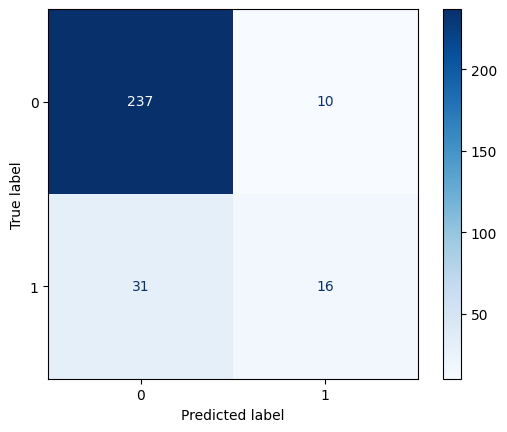

In [69]:
#logistic regression

# Create an empty dictionary to collect our final scores
model_scores = {}

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# The 'y' and 'X' variables are correctly prepared in previous cells (2pSFFXCqmcE6).
# Redefining them here using 'df_cleaned' is unnecessary and could lead to inconsistencies.
# Removing these lines to avoid confusion and ensure the model uses the preprocessed X_train_scaled and y_train.

# Train Model
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

# Save Metrics
model_scores["Logistic Regression"] = {
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1-Score": f1_score(y_test, y_pred_lr),
    "ROC-AUC": roc_auc_score(y_test, y_prob_lr)
}

# Print Metrics & Plot
print("Logistic Regression Metrics:")
print(model_scores["Logistic Regression"])
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap="Blues")

Decision Tree Metrics:
{'Accuracy': 0.7857142857142857, 'Precision': 0.34615384615384615, 'Recall': 0.3829787234042553, 'F1-Score': 0.36363636363636365, 'ROC-AUC': np.float64(0.6226634507709535)}


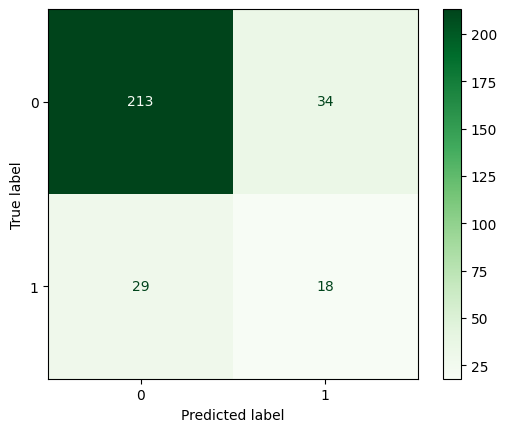

In [70]:
#decision tree

from sklearn.tree import DecisionTreeClassifier

# Train Model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)

# Predict
y_pred_dt = dt.predict(X_test_scaled)
y_prob_dt = dt.predict_proba(X_test_scaled)[:, 1]

# Save Metrics
model_scores["Decision Tree"] = {
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt),
    "Recall": recall_score(y_test, y_pred_dt),
    "F1-Score": f1_score(y_test, y_pred_dt),
    "ROC-AUC": roc_auc_score(y_test, y_prob_dt)
}

# Print Metrics & Plot
print("Decision Tree Metrics:")
print(model_scores["Decision Tree"])
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, cmap="Greens")

Random Forest Metrics:
{'Accuracy': 0.826530612244898, 'Precision': 0.3, 'Recall': 0.06382978723404255, 'F1-Score': 0.10526315789473684, 'ROC-AUC': np.float64(0.7445516409682144)}


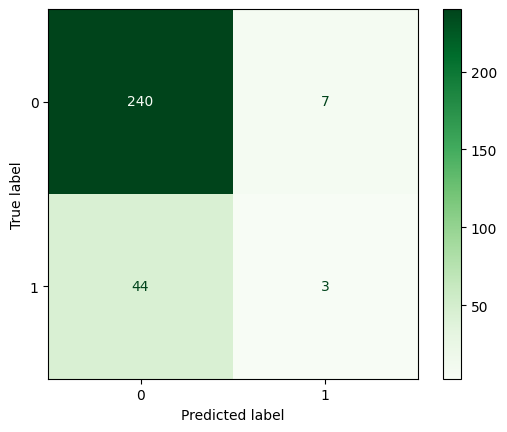

In [71]:
#random forest

from sklearn.ensemble import RandomForestClassifier

# Train Model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

# Predict
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

# Save Metrics
model_scores["Random Forest"] = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1-Score": f1_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_prob_rf)
}

# Print Metrics & Plot
print("Random Forest Metrics:")
print(model_scores["Random Forest"])
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap="Greens")

XGBoost Metrics:
{'Accuracy': 0.8605442176870748, 'Precision': 0.6666666666666666, 'Recall': 0.2553191489361702, 'F1-Score': 0.36923076923076925, 'ROC-AUC': np.float64(0.7542423981393745)}


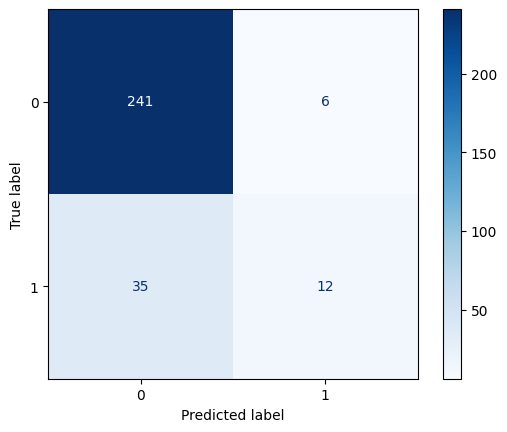

In [72]:
#xgboost

from xgboost import XGBClassifier

# Train Model
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_scaled, y_train)

# Predict
y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

# Save Metrics
model_scores["XGBoost"] = {
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb),
    "F1-Score": f1_score(y_test, y_pred_xgb),
    "ROC-AUC": roc_auc_score(y_test, y_prob_xgb)
}

# Print Metrics & Plot
print("XGBoost Metrics:")
print(model_scores["XGBoost"])
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, cmap="Blues")

In [73]:
# Convert dictionary to dataframe and transpose it for a structured summary
df_results = pd.DataFrame(model_scores).T
df_results.round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.8605,0.6154,0.3404,0.4384,0.8119
Decision Tree,0.7857,0.3462,0.3830,0.3636,0.6227
Random Forest,0.8265,0.3000,0.0638,0.1053,0.7446
XGBoost,0.8605,0.6667,0.2553,0.3692,0.7542


---

**WEEK 1 - PROJECT 4 [Model Evaluation]**

---

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

#test=20%, remaining=80%
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#remaining 80% = validation=20%, train=60%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

#scaler will now only scale truly continuous features
#because get_dummies turns categoricals into 0s and 1s, scaling them is unnecessary

continuous_cols = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'JobLevel',
    'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
    'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
    'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

#Create copies of dataframes to scale cleanly
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

#Initialize and fit scaler only on continuous features
scaler = StandardScaler()
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_val_scaled[continuous_cols] = scaler.transform(X_val[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

print("Data successfully preprocessed!")
print(f"Train shape: {X_train_scaled.shape} | Val shape: {X_val_scaled.shape} | Test shape: {X_test_scaled.shape}")

Data successfully preprocessed!
Train shape: (882, 57) | Val shape: (294, 57) | Test shape: (294, 57)


In [75]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np

rf_model = RandomForestClassifier(random_state=42)
cv_accuracies = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print("------ 5 fold cross validation results ------")
print(f"Score for each of the 5 folds: {cv_accuracies}")
print(f"Average accuracy: {np.mean(cv_accuracies):.4f}")
print(f"Standard Deviation: {np.std(cv_accuracies):.4f}")


------ 5 fold cross validation results ------
Score for each of the 5 folds: [0.85310734 0.84745763 0.86363636 0.86363636 0.85795455]
Average accuracy: 0.8572
Standard Deviation: 0.0062


------ Random forest validation metrics (threshold = 50%) ------
Accuracy: 0.8673
Precision: 0.8333
Recall: 0.2128
F1: 0.3390

Plotting Confusion Matrix:


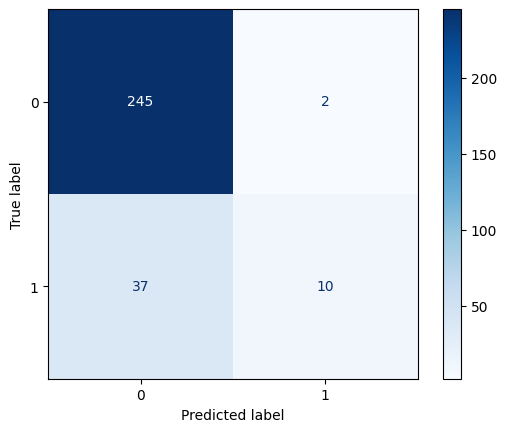

In [76]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train_scaled, y_train)
y_val_pred=rf_model.predict(X_val_scaled)

print("------ Random forest validation metrics (threshold = 50%) ------")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred):.4f}")
print(f"Recall: {recall_score(y_val, y_val_pred):.4f}")
print(f"F1: {f1_score(y_val, y_val_pred):.4f}")

print("\nPlotting Confusion Matrix:")
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred, cmap="Blues")
plt.show()

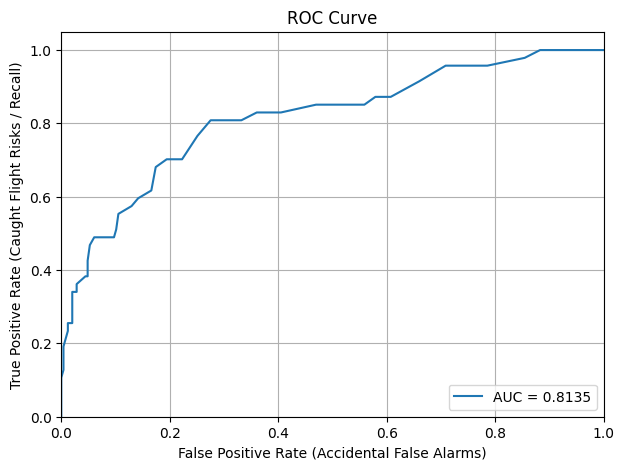

In [77]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

rf_model.fit(X_train_scaled, y_train)

y_val_probs = rf_model.predict_proba(X_val_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_val_probs)

roc_auc = roc_auc_score(y_val, y_val_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Accidental False Alarms)')
plt.ylabel('True Positive Rate (Caught Flight Risks / Recall)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [78]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

#raw probabilities (the probability of quitting)
# [:, 1] grabs the second column, which belongs to Attrition = 1
y_val_probabilities = rf_model.predict_proba(X_val_scaled)[:, 1]

#empty list to store the scoring results for each threshold
tuning_results = []

#array of thresholds from 0.05 to 0.95, stepping by 0.01
threshold_grid = np.arange(0.05, 0.95, 0.01)
for threshold in threshold_grid:
    # If probability is greater than the current threshold,
    # chances of leaving is more, predict 1, else 0
    simulated_predictions = (y_val_probabilities >= threshold).astype(int)

    #core metrics for this specific threshold
    precision = precision_score(y_val, simulated_predictions, zero_division=0)
    recall = recall_score(y_val, simulated_predictions, zero_division=0)
    f1 = f1_score(y_val, simulated_predictions, zero_division=0)

    # Store the results in a dictionary
    tuning_results.append({
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

#convert the results into a clean DataFrame for easy sorting
df_tuning = pd.DataFrame(tuning_results)

#find the row where the F1-Score is at its absolute highest
best_row = df_tuning.loc[df_tuning['F1-Score'].idxmax()]
best_recall = df_tuning.loc[df_tuning['Recall'].idxmax()]

print("-------------- THRESHOLD TUNING REPORT --------------\n")
print(f"Optimized Threshold found at: {best_row['Threshold']:.2f}")
print(f"-> Best F1-Score:        {best_row['F1-Score']:.4f}")
print(f"-> Associated Precision: {best_row['Precision']:.4f}")
print(f"-> Associated Recall:    {best_row['Recall']:.4f}\n")
print(f"Best recall score {best_recall['Recall']:.4f} found at Threshold: {best_recall['Threshold']:.2f}")
print(f"-> Associated Precision score: {best_recall['Precision']:.4f}\n")
print("-------------------------------------------------------")

-------------- THRESHOLD TUNING REPORT --------------

Optimized Threshold found at: 0.32
-> Best F1-Score:        0.5412
-> Associated Precision: 0.6053
-> Associated Recall:    0.4894

Best recall score 1.0000 found at Threshold: 0.05
-> Associated Precision score: 0.1691

-------------------------------------------------------


In [79]:
import numpy as np
import pandas as pd

threshold=best_row['Threshold'] #0.32

#checks if the probabilities>=0.32, if so, it becomes 1[will leave]
custom_predictions = (y_val_probabilities >= threshold).astype(int)

df_error_analysis = X_val.copy()
df_error_analysis['True_Attrition'] = y_val.values #raw actual attrition values
df_error_analysis['Predicted_Attrition'] = custom_predictions #predicted above (0,1)
df_error_analysis['Leaving_Probability'] = y_val_probabilities #predicted probabilities

#keep the failures only
df_failures = df_error_analysis[df_error_analysis['True_Attrition'] != df_error_analysis['Predicted_Attrition']].copy()

#calculate error score |(0,1)-predicted probability|
df_failures['Error_Score'] = np.abs(df_failures['True_Attrition'] - df_failures['Leaving_Probability'])

#sort top 10 error scores
df_top_10_errors = df_failures.sort_values(by='Error_Score', ascending=False).head(10)

#top features with high association
display_cols = ['True_Attrition', 'Predicted_Attrition', 'Leaving_Probability', 'Error_Score', 'OverTime', 'MonthlyIncome', 'Age', 'DistanceFromHome']
print("-------- Error Analysis Table ---------")
print(f"Based on threshold: {threshold:.2f}")
df_top_10_errors[display_cols]

-------- Error Analysis Table ---------
Based on threshold: 0.32


,True_Attrition,Predicted_Attrition,Leaving_Probability,Error_Score,OverTime,MonthlyIncome,Age,DistanceFromHome
568,1,0,0.06,0.94,1,19859,55,2
1298,1,0,0.07,0.93,0,8926,46,21
495,1,0,0.09,0.91,0,3041,27,2
317,1,0,0.09,0.91,0,4941,52,8
528,1,0,0.10,0.90,1,6796,50,8
749,1,0,0.10,0.90,0,19845,52,2
366,1,0,0.12,0.88,0,9355,41,4
666,1,0,0.15,0.85,1,4171,22,3
791,1,0,0.17,0.83,1,9582,35,4
981,1,0,0.19,0.81,1,4614,35,18


In [80]:
import pandas as pd

def predict_attrition(
    age,
    income,
    distance,
    years_worked,
    years_company,
    overtime,
    satisfaction,
    worklife,
    base_sample_scaled_df,
    scaler_obj,
    model,
    continuous_cols_list
):


    sample = base_sample_scaled_df.copy()

    # Undo scaling
    continuous_scaled = sample[continuous_cols_list]

    continuous_original = scaler_obj.inverse_transform(
        continuous_scaled
    )

    continuous_df = pd.DataFrame(
        continuous_original,
        columns=continuous_cols_list,
        index=sample.index
    )

    # Update numeric inputs
    continuous_df.loc[:, 'Age'] = age
    continuous_df.loc[:, 'MonthlyIncome'] = income
    continuous_df.loc[:, 'DistanceFromHome'] = distance
    continuous_df.loc[:, 'TotalWorkingYears'] = years_worked
    continuous_df.loc[:, 'YearsAtCompany'] = years_company

    # Scale back
    sample[continuous_cols_list] = scaler_obj.transform(
        continuous_df
    )

    # Update encoded categorical values
    if 'OverTime_Yes' in sample.columns:
        sample['OverTime_Yes'] = 1 if overtime else 0

    if 'JobSatisfaction' in sample.columns:
        sample['JobSatisfaction'] = satisfaction

    if 'WorkLifeBalance' in sample.columns:
        sample['WorkLifeBalance'] = worklife

    probs = model.predict_proba(sample)[0]

    print(f"Stay Probability: {probs[0]:.2%}")
    print(f"Leave Probability: {probs[1]:.2%}")

    pred = model.predict(sample)

    return (
        "Employee likely to leave"
        if pred[0] == 1
        else
        "Employee likely to stay"
    )


age = float(input("Age (18–60): "))
income = float(input("Monthly Income (1000–20,000): "))
distance = float(input("Distance From Home (1-30): "))
years_worked = float(input("Total Working Years (0-40): "))
years_company = float(input("Years At Company (0-40): "))

overtime = input(
"Overtime? (yes/no): "
).lower() == "yes"

satisfaction = int(
input("Job Satisfaction (1-4): ")
)

worklife = int(
input("Work Life Balance (1-4): ")
)

result = predict_attrition(
age,
income,
distance,
years_worked,
years_company,
overtime,
satisfaction,
worklife,
X_test_scaled[0:1],
scaler,
lr,
continuous_cols
)

print("\nPrediction:", result)

Age (18–60): 21
Monthly Income (1000–20,000): 10000
Distance From Home (1-30): 30
Total Working Years (0-40): 0
Years At Company (0-40): 0
Overtime? (yes/no): yes
Job Satisfaction (1-4): 3
Work Life Balance (1-4): 2
Stay Probability: 84.79%
Leave Probability: 15.21%

Prediction: Employee likely to stay


**WEEK 1 – PROJECT 5 [Complete Project]**
---

Objective:
Predict employee attrition using supervised machine learning.

Dataset:
IBM HR Employee Attrition Dataset

Workflow:
1. EDA
2. Missing value handling
3. Outlier analysis
4. Encoding and scaling
5. Feature importance hypothesis
6. Model training
7. Evaluation

Models:
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

---
Model Comparison

---
Logistic Regression

Accuracy: 0.8605

F1 Score: 0.4384

---

Decision Tree

Accuracy: 0.7857

F1 Score: 0.3636

---
Random Forest

Accuracy: 0.8265

F1 Score: 0.1053

---
XGBoost

Accuracy: 0.8605

F1 Score: 0.3692

---
Best Model: Logistic Regression

---
Evaluation Metrics:
- Accuracy
- Precision
- Recall
- F1
- ROC-AUC

Conclusion:
The model can predict employee attrition and identify influential workplace factors.